# Module 4 — Stratospheric Ozone Chemistry: the Chapman Mechanism
### B4 Chemistry in the Atmosphere · companion notebook

Covers: Exercise 5 (O<->O3 interconversion timescale), Exercise 6 (steady-state Chapman
[O3]), and a generic catalytic-cycle odd-oxygen-loss calculator for NOx/HOx/ClOx.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['font.size'] = 11

def M_of_z(z_km, M0=2.4e19, H_km=7):
    return M0 * np.exp(-z_km / H_km)

def T_of_z(z_km):
    # crude stratospheric temperature profile: ~220 K at 20 km rising to ~270 K at 50 km
    return 220 + (z_km - 20) * (270 - 220) / 30

def rate_k3(T):
    return 6e-34 * (300/T)**2

def rate_k4(T):
    return 1.0e-11 * np.exp(-2100/T)

J2 = 5e-10
J3 = 2e-3

## Exercise 5 — O <-> O3 interconversion timescale vs altitude

$$\tau = (k_f + k_b)^{-1}, \qquad k_f = k_3[M][O_2],\ k_b = J_3$$

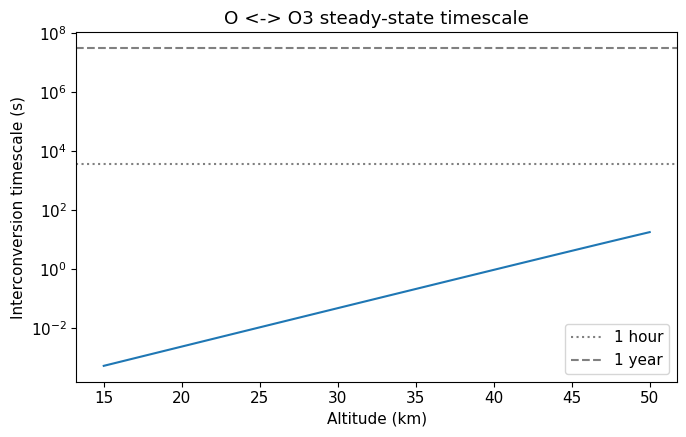

tau at 30 km = 0.04 s (notes: 0.43 s)


In [2]:
z_range = np.linspace(15, 50, 50)
tau = []
for z in z_range:
    M = M_of_z(z)
    O2 = 0.2 * M
    T = T_of_z(z)
    kf = rate_k3(T) * M * O2
    kb = J3
    tau.append(1/(kf+kb))

plt.figure()
plt.semilogy(z_range, tau)
plt.axhline(3600, color='gray', ls=':', label='1 hour')
plt.axhline(3600*24*365, color='gray', ls='--', label='1 year')
plt.xlabel('Altitude (km)')
plt.ylabel('Interconversion timescale (s)')
plt.title('O <-> O3 steady-state timescale')
plt.legend()
plt.tight_layout()
plt.show()

# Check the specific 30 km value quoted in the notes
M30 = M_of_z(30); O2_30 = 0.2*M30; T30 = 225
kf30 = rate_k3(T30)*M30*O2_30
tau30 = 1/(kf30+J3)
print(f"tau at 30 km = {tau30:.2f} s (notes: 0.43 s)")

## Exercise 6 — steady-state Chapman ozone profile

$$[O_3] = \sqrt{\frac{J_2[O_2] k_3[O_2][M]}{k_4 J_3}}$$

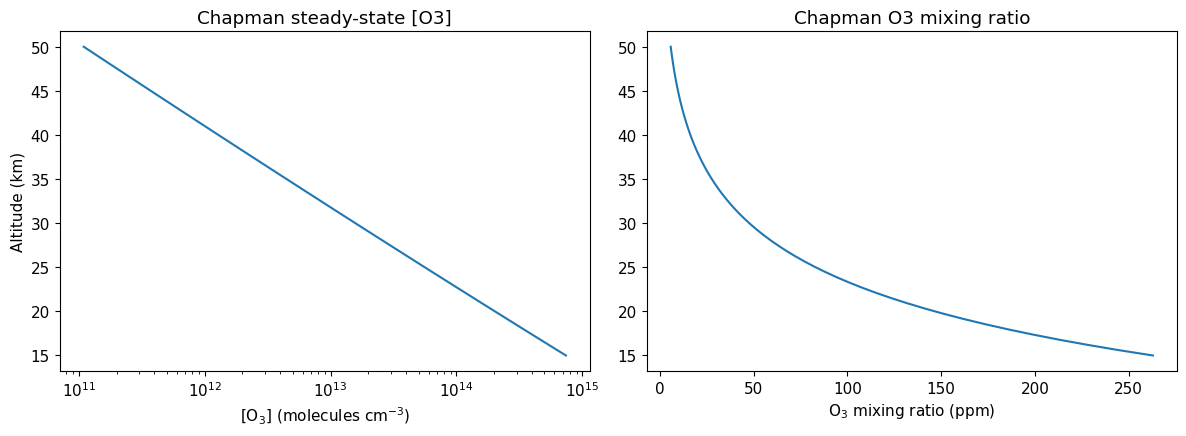

Peak O3 mixing ratio (Chapman-only): 262.9 ppm at 15 km
The real atmosphere peaks around ~10 ppm -- the notes flag that Chapman-only
calculations OVERESTIMATE stratospheric ozone because reaction 4.4 only accounts
for ~25% of real odd-oxygen loss (catalytic cycles supply the rest).


In [3]:
def O3_chapman(z_km):
    M = M_of_z(z_km)
    O2 = 0.2 * M
    T = T_of_z(z_km)
    k3 = rate_k3(T)
    k4 = rate_k4(T)
    return np.sqrt(J2*O2*k3*O2*M / (k4*J3))

z_range = np.linspace(15, 50, 60)
O3_profile = np.array([O3_chapman(z) for z in z_range])
mixing_ratio = O3_profile / np.array([M_of_z(z) for z in z_range])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].semilogx(O3_profile, z_range)
axes[0].set_xlabel('[O$_3$] (molecules cm$^{-3}$)')
axes[0].set_ylabel('Altitude (km)')
axes[0].set_title('Chapman steady-state [O3]')

axes[1].plot(mixing_ratio*1e6, z_range)
axes[1].set_xlabel('O$_3$ mixing ratio (ppm)')
axes[1].set_title('Chapman O3 mixing ratio')
plt.tight_layout()
plt.show()

print(f"Peak O3 mixing ratio (Chapman-only): {mixing_ratio.max()*1e6:.1f} ppm at {z_range[np.argmax(mixing_ratio)]:.0f} km")
print("The real atmosphere peaks around ~10 ppm -- the notes flag that Chapman-only")
print("calculations OVERESTIMATE stratospheric ozone because reaction 4.4 only accounts")
print("for ~25% of real odd-oxygen loss (catalytic cycles supply the rest).")

## A generic catalytic-cycle odd-oxygen-loss calculator

$$\left.\frac{d[O_x]}{dt}\right|_X = -2k_b[XO][O]$$

for any catalytic family X (NOx, HOx, ClOx, ...). We compare the *relative* importance of
different families for representative (illustrative) concentrations at a chosen altitude.

Family                  d[Ox]/dt (cm^-3 s^-1)
NOx (NO2+O)                         2.000e+06
HOx (HO2+O)                         1.200e+05
ClOx (ClO+O)                        6.000e+03


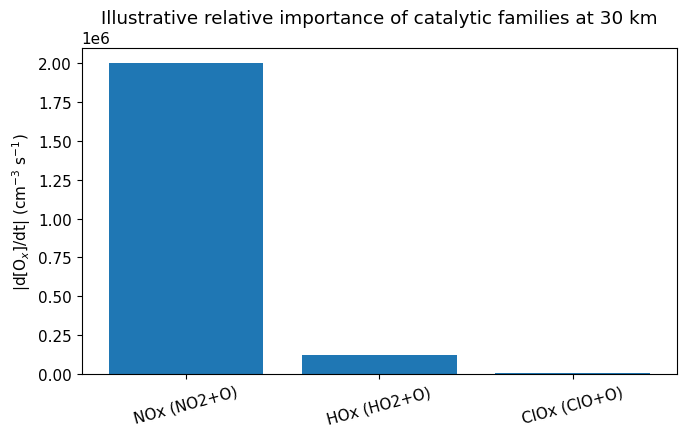


These numbers are illustrative (not measured [XO], [O] profiles) -- Exercise 3
asks you to substitute real values from the notes' Figs 4.4/4.6/4.9.


In [4]:
def Ox_loss_rate(kb, XO_conc, O_conc):
    return 2 * kb * XO_conc * O_conc

# Illustrative rate constants (kb, i.e. XO + O -> X + O2) and representative [XO], [O]
# at ~30 km -- NOT literature values, just illustrative magnitudes for comparison.
families = {
    'NOx (NO2+O)':  dict(kb=1e-11, XO=1e9),
    'HOx (HO2+O)':  dict(kb=6e-11, XO=1e7),
    'ClOx (ClO+O)': dict(kb=3e-11, XO=1e6),
}
O_conc = 1e8   # molecules/cm^3, illustrative [O] at 30 km

print(f"{'Family':20s}{'d[Ox]/dt (cm^-3 s^-1)':>25s}")
losses = {}
for name, p in families.items():
    rate = Ox_loss_rate(p['kb'], p['XO'], O_conc)
    losses[name] = rate
    print(f"{name:20s}{rate:25.3e}")

plt.figure()
plt.bar(losses.keys(), losses.values())
plt.ylabel('|d[O$_x$]/dt| (cm$^{-3}$ s$^{-1}$)')
plt.title('Illustrative relative importance of catalytic families at 30 km')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\nThese numbers are illustrative (not measured [XO], [O] profiles) -- Exercise 3")
print("asks you to substitute real values from the notes' Figs 4.4/4.6/4.9.")

## Exercises

1. **Where does steady state break down?** Extend the Exercise-5 plot down to 10 km. At what
   altitude does the interconversion timescale exceed a day? A year? Relate this to the notes'
   statement that O-atom chemistry becomes "very inefficient" at low altitudes.

2. **Comparing to real profiles.** Look up (or estimate from Fig 4.1/4.2 in the notes) a realistic
   observed O3 number-density profile, and plot it alongside your `O3_chapman` curve on the same
   axes. At what altitude is the Chapman-only overestimate largest?

3. **Realistic catalytic rates.** Replace the illustrative `kb` and `[XO]` values in the
   `families` dictionary with literature rate constants (e.g. JPL evaluation) and typical
   modelled [XO] from Figs 4.4 (NOy), 4.6 (HOx) and 4.9 (ClOx) at a specific altitude of your
   choice, and redo the bar chart. Does the ranking match the qualitative statement in §4.7 that
   different families dominate in different altitude bands?

4. **Reservoir partitioning.** Suppose 90% of total inorganic chlorine at some altitude is locked
   up as HCl/ClONO2 reservoirs, with only 10% as active Cl/ClO. How does this change the
   *effective* odd-oxygen loss rate compared to a hypothetical case with 0% reservoir
   partitioning? (Hint: only the active ClO concentration enters the loss-rate formula.)